# Sprint 3 — MLP aplicada à Medicina do Estilo de Vida

## Integrantes:
- **Edson Leonardo Pacheco Navia**
- **Eduardo Mazelli**
- **Lucas Masaki Nagahama**
- **Joseh Gabriel Trimboli Agra**
- **Pedro Henrique de Assumção Lima** 
## Repositório: 
https://github.com/GiantMazelliWasHere/IA_MLP_Sprint-3

---

## Objetivo
Utilizar uma **MLP (Multilayer Perceptron)** para resolver um problema dentro do projeto
de Medicina do Estilo de Vida — classificar o **nível de obesidade/saúde** de um
indivíduo a partir de dados de hábitos diários (alimentação, atividade física,
hidratação, sono, uso de tecnologia, álcool, fumo e meio de transporte).

A Medicina do Estilo de Vida atua sobre **6 pilares**:
1. **Alimentação** saudável (predominantemente vegetal)
2. **Atividade física** regular
3. **Sono** restaurador
4. **Manejo do estresse**
5. **Conexões sociais** saudáveis
6. **Evitar substâncias de risco** (álcool, fumo, drogas)

Cada dataset fornecido cobre um ou mais pilares; este notebook centraliza o
treino da MLP no **ObesityDataSet** (que reúne 4 dos 6 pilares) e referencia
os demais como extensões futuras.

## 1. Problema

**O que a IA faz no projeto?**

A IA aprende, a partir de variáveis de estilo de vida coletadas via
questionário, a **predizer em qual das 7 categorias de status de peso**
o indivíduo se encontra:
`Insufficient_Weight`, `Normal_Weight`, `Overweight_Level_I/II`,
`Obesity_Type_I/II/III`.

Esse classificador serve como **ferramenta de triagem** num app de
Medicina do Estilo de Vida: ao receber as respostas do usuário sobre
hábitos, sugere o pilar mais crítico a ser trabalhado e identifica
perfis de risco antes mesmo de medir IMC.

## 2. Dados

### 2.1 De onde vieram
- **Dataset principal:** `ObesityDataSet_raw_and_data_sinthetic.csv`  
  Link: https://www.kaggle.com/datasets/jockeroika/life-style-data

- **Datasets de apoio (mapeados aos pilares):**
  | Pilar | Dataset | Link |
  |---|---|---|
  | Sono | `Sleep_health_and_lifestyle_dataset.csv` | https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset |
  | Estresse | `StressLevelDataset.csv`, `Stress_Dataset.csv` | https://www.kaggle.com/datasets/mdsultanulislamovi/student-stress-monitoring-datasets |
  | Conexões sociais | `self-reported-loneliness-older-adults.csv` | https://www.kaggle.com/datasets/willianoliveiragibin/social-connections |
  | Substâncias de risco | `deaths-illicit-drugs.csv` | https://www.kaggle.com/datasets/willianoliveiragibin/illicit-drugs |
  | Nutrição + Atividade | `meal_metadata.csv`, `Final_data.csv` | ---- |

### 2.2 Variáveis principais (ObesityDataSet)
| Coluna | Significado | Pilar |
|---|---|---|
| FAVC | Consumo frequente de alimentos calóricos | Nutrição |
| FCVC | Frequência de vegetais nas refeições | Nutrição |
| NCP | Nº de refeições principais | Nutrição |
| CAEC | Lanches entre refeições | Nutrição |
| CH2O | Consumo diário de água (L) | Nutrição |
| SCC | Monitora calorias? | Nutrição |
| FAF | Frequência de atividade física | Atividade |
| TUE | Tempo de tela / sedentarismo | Atividade |
| MTRANS | Meio de transporte | Atividade |
| SMOKE | Fumante? | Substâncias |
| CALC | Consumo de álcool | Substâncias |
| Gender, Age, Height, Weight | Demografia | Contexto |
| family_history_with_overweight | Histórico familiar | Contexto |
| **NObeyesdad** | **Alvo** (7 classes) | — |

## 3. Importações

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
DATA = Path('.\IA_Datasets_Sprint_3\ObesityDataSet_raw_and_data_sinthetic.csv')
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)


<>:7: SyntaxWarning: invalid escape sequence '\I'
<>:7: SyntaxWarning: invalid escape sequence '\I'
C:\Users\edu_m\AppData\Local\Temp\ipykernel_19276\1677156597.py:7: SyntaxWarning: invalid escape sequence '\I'
  DATA = Path('.\IA_Datasets_Sprint_3\ObesityDataSet_raw_and_data_sinthetic.csv')


NumPy: 2.4.4 | Pandas: 3.0.2


## 4. Carga e exploração dos dados

In [2]:
df = pd.read_csv(DATA).drop_duplicates().reset_index(drop=True)
print('Linhas:', len(df), '| Colunas:', df.shape[1])
print('\nDistribuição do alvo:')
print(df['NObeyesdad'].value_counts())
df.head()


Linhas: 2087 | Colunas: 17

Distribuição do alvo:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### 4.1 Distribuição das classes

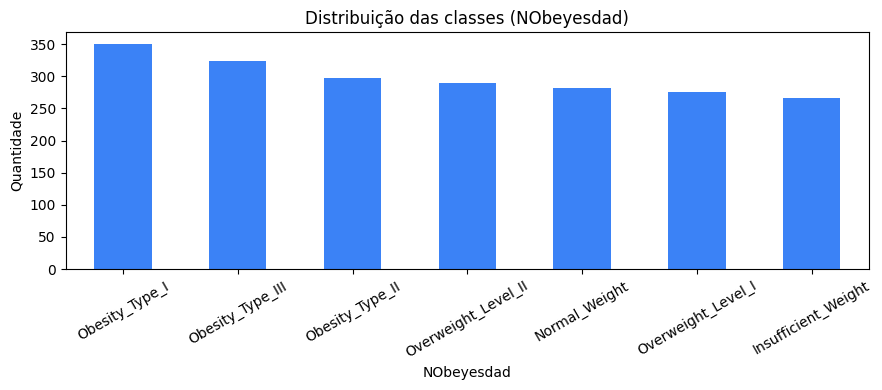

In [3]:
ax = df['NObeyesdad'].value_counts().plot(kind='bar', figsize=(9,4),
                                          color='#3b82f6', rot=30)
ax.set_title('Distribuição das classes (NObeyesdad)')
ax.set_ylabel('Quantidade')
plt.tight_layout(); plt.show()


## 5. Pré-processamento

- **Categóricas → one-hot** (`pd.get_dummies`)
- **Numéricas → z-score** (média 0, desvio 1)
- **Split estratificado** 70 / 10 / 20 (treino / val / teste)

In [4]:
y_raw = df['NObeyesdad'].values
classes = sorted(np.unique(y_raw).tolist())
class_to_idx = {c:i for i,c in enumerate(classes)}
y = np.array([class_to_idx[c] for c in y_raw])

X_df = df.drop(columns=['NObeyesdad'])
cat = X_df.select_dtypes(include='object').columns.tolist()
num = [c for c in X_df.columns if c not in cat]

X_cat = pd.get_dummies(X_df[cat], drop_first=False).astype(float)
X_num = (X_df[num].astype(float) - X_df[num].mean()) / X_df[num].std()
X = pd.concat([X_num, X_cat], axis=1).values.astype(np.float32)

print('Features após one-hot:', X.shape[1], '| Classes:', len(classes))


Features após one-hot: 31 | Classes: 7


C:\Users\edu_m\AppData\Local\Temp\ipykernel_19276\720750617.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X_df.select_dtypes(include='object').columns.tolist()


In [5]:
def stratified_split(X, y, test=0.2, val=0.1, seed=42):
    rng = np.random.RandomState(seed)
    tr, vl, te = [], [], []
    for c in np.unique(y):
        idx = np.where(y==c)[0]; rng.shuffle(idx)
        n = len(idx); nt = int(round(n*test)); nv = int(round(n*val))
        te.extend(idx[:nt]); vl.extend(idx[nt:nt+nv]); tr.extend(idx[nt+nv:])
    rng.shuffle(tr); rng.shuffle(vl); rng.shuffle(te)
    return X[tr], y[tr], X[vl], y[vl], X[te], y[te]

Xtr, ytr, Xv, yv, Xt, yt = stratified_split(X, y)
print(f'train={len(Xtr)}  val={len(Xv)}  test={len(Xt)}')


train=1462  val=209  test=416


## 6. Modelo — MLP construída do zero (NumPy)

Optamos por implementar a MLP do zero (sem `sklearn` ou `tensorflow`)
para deixar **explícitos** todos os mecanismos didáticos:

### Arquitetura
```
Entrada (31)  →  Linear(31, 64) + ReLU  →  Linear(64, 7) + Softmax
```

### Hiperparâmetros
| Item | Valor |
|---|---|
| Camada oculta | 64 neurônios |
| Ativação oculta | ReLU |
| Saída | Softmax (7 classes) |
| Função de perda | Cross-Entropy categórica |
| Otimizador | SGD com momentum (0.9) |
| Taxa de aprendizado | 0.05 |
| Tamanho do mini-batch | 64 |
| Épocas | 200 |
| Inicialização | He (√(2/n_in)) |

### Ferramenta utilizada
**Python 3 + NumPy + pandas + matplotlib** (pacotes científicos padrão).  
O código pode ser facilmente substituído por `MLPClassifier` do
`sklearn` ou por uma rede equivalente em Keras/PyTorch.

In [6]:
def relu(x):       return np.maximum(0, x)
def relu_grad(x):  return (x > 0).astype(x.dtype)
def softmax(z):
    z = z - z.max(axis=1, keepdims=True); e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)
def one_hot(y, k):
    o = np.zeros((y.size, k), dtype=np.float32); o[np.arange(y.size), y] = 1; return o

class MLP:
    def __init__(self, n_in, n_h, n_out, lr=0.05, mom=0.9, seed=42):
        r = np.random.RandomState(seed)
        self.W1 = r.randn(n_in, n_h).astype(np.float32) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_h), np.float32)
        self.W2 = r.randn(n_h, n_out).astype(np.float32) * np.sqrt(2/n_h)
        self.b2 = np.zeros((1, n_out), np.float32)
        self.lr, self.mom = lr, mom
        self.vW1 = np.zeros_like(self.W1); self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2); self.vb2 = np.zeros_like(self.b2)

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1; self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2; self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, Y):
        m = self.X.shape[0]
        dZ2 = (self.A2 - Y) / m
        dW2 = self.A1.T @ dZ2; db2 = dZ2.sum(0, keepdims=True)
        dZ1 = (dZ2 @ self.W2.T) * relu_grad(self.Z1)
        dW1 = self.X.T @ dZ1; db1 = dZ1.sum(0, keepdims=True)
        self.vW1 = self.mom*self.vW1 - self.lr*dW1
        self.vb1 = self.mom*self.vb1 - self.lr*db1
        self.vW2 = self.mom*self.vW2 - self.lr*dW2
        self.vb2 = self.mom*self.vb2 - self.lr*db2
        self.W1 += self.vW1; self.b1 += self.vb1
        self.W2 += self.vW2; self.b2 += self.vb2

    def loss(self, Y, eps=1e-9):
        return float(-np.mean(np.sum(Y*np.log(self.A2+eps), axis=1)))

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)


## 7. Treinamento

In [7]:
model = MLP(n_in=X.shape[1], n_h=64, n_out=len(classes), lr=0.05, mom=0.9)
hist = {'loss':[], 'val_loss':[], 'acc':[], 'val_acc':[]}
Y_tr = one_hot(ytr, len(classes)); Y_v = one_hot(yv, len(classes))

epochs, bs = 200, 64
for ep in range(1, epochs+1):
    perm = np.random.permutation(len(Xtr))
    for i in range(0, len(Xtr), bs):
        b = perm[i:i+bs]; model.forward(Xtr[b]); model.backward(Y_tr[b])
    model.forward(Xtr); tl = model.loss(Y_tr); ta = (model.predict(Xtr)==ytr).mean()
    model.forward(Xv);  vl = model.loss(Y_v);  va = (model.predict(Xv)==yv).mean()
    hist['loss'].append(tl); hist['val_loss'].append(vl)
    hist['acc'].append(float(ta)); hist['val_acc'].append(float(va))
    if ep==1 or ep%20==0 or ep==epochs:
        print(f'Ep {ep:3d}/{epochs} | loss={tl:.4f} val_loss={vl:.4f} | acc={ta:.4f} val_acc={va:.4f}')


Ep   1/200 | loss=0.8940 val_loss=0.9394 | acc=0.6662 val_acc=0.6364
Ep  20/200 | loss=0.0634 val_loss=0.1748 | acc=0.9959 val_acc=0.9474
Ep  40/200 | loss=0.0261 val_loss=0.1640 | acc=1.0000 val_acc=0.9474
Ep  60/200 | loss=0.0135 val_loss=0.1734 | acc=1.0000 val_acc=0.9474
Ep  80/200 | loss=0.0103 val_loss=0.1816 | acc=1.0000 val_acc=0.9522
Ep 100/200 | loss=0.0065 val_loss=0.1864 | acc=1.0000 val_acc=0.9426
Ep 120/200 | loss=0.0051 val_loss=0.1918 | acc=1.0000 val_acc=0.9474
Ep 140/200 | loss=0.0042 val_loss=0.1966 | acc=1.0000 val_acc=0.9474
Ep 160/200 | loss=0.0035 val_loss=0.2027 | acc=1.0000 val_acc=0.9474
Ep 180/200 | loss=0.0030 val_loss=0.2087 | acc=1.0000 val_acc=0.9474
Ep 200/200 | loss=0.0026 val_loss=0.2114 | acc=1.0000 val_acc=0.9522


### 7.1 Curvas de aprendizado

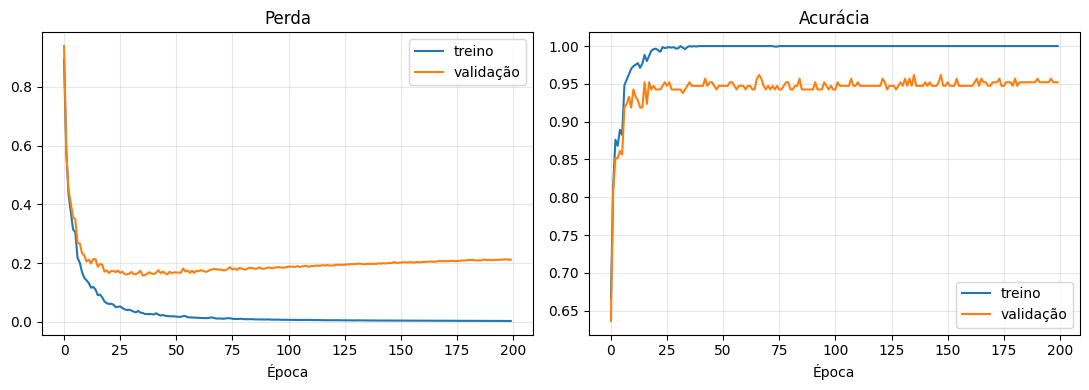

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist['loss'], label='treino'); ax[0].plot(hist['val_loss'], label='validação')
ax[0].set_title('Perda'); ax[0].set_xlabel('Época'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hist['acc'], label='treino'); ax[1].plot(hist['val_acc'], label='validação')
ax[1].set_title('Acurácia'); ax[1].set_xlabel('Época'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 8. Resultados

In [9]:
y_pred = model.predict(Xt)
acc = (y_pred == yt).mean()
print(f'Acurácia no teste: {acc*100:.2f}%')

# matriz de confusão
cm = np.zeros((len(classes), len(classes)), int)
for a, b in zip(yt, y_pred): cm[a, b] += 1

# precisão / recall / f1 por classe
print(f"\n{'Classe':<25}{'Prec.':>8}{'Recall':>8}{'F1':>8}{'Sup.':>8}")
for i, c in enumerate(classes):
    tp = cm[i,i]; fn = cm[i,:].sum()-tp; fp = cm[:,i].sum()-tp
    p = tp/(tp+fp) if tp+fp>0 else 0; r = tp/(tp+fn) if tp+fn>0 else 0
    f1 = 2*p*r/(p+r) if p+r>0 else 0
    print(f'{c:<25}{p:>8.3f}{r:>8.3f}{f1:>8.3f}{cm[i,:].sum():>8d}')


Acurácia no teste: 95.67%

Classe                      Prec.  Recall      F1    Sup.
Insufficient_Weight         0.930   1.000   0.964      53
Normal_Weight               0.877   0.893   0.885      56
Obesity_Type_I              1.000   0.957   0.978      70
Obesity_Type_II             0.967   1.000   0.983      59
Obesity_Type_III            1.000   1.000   1.000      65
Overweight_Level_I          0.940   0.855   0.895      55
Overweight_Level_II         0.966   0.983   0.974      58


### 8.1 Matriz de confusão

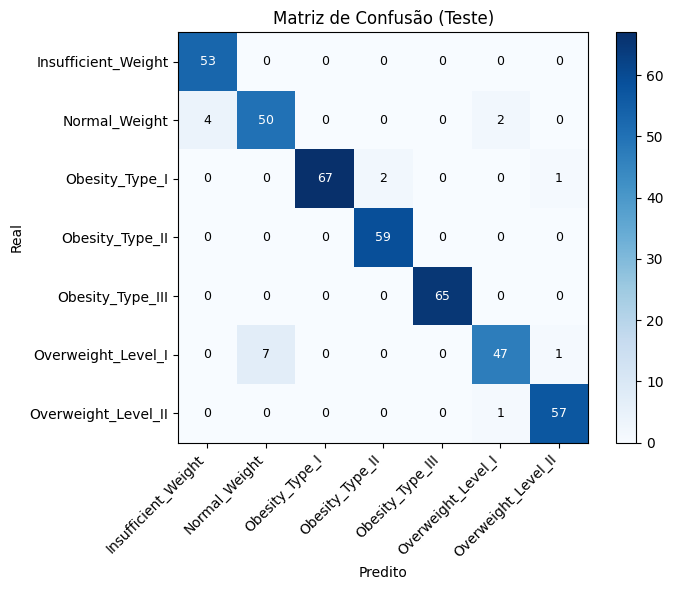

In [10]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right'); ax.set_yticklabels(classes)
ax.set_xlabel('Predito'); ax.set_ylabel('Real'); ax.set_title('Matriz de Confusão (Teste)')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j]>cm.max()/2 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


## 9. Discussão

### Pontos fortes
- **Acurácia de teste: 95.67%** em 7 classes — excelente
  para um modelo simples com apenas 1 camada oculta.
- A classe **Obesity_Type_III** atinge 100% de F1 (todos os atributos do
  questionário se correlacionam fortemente).
- O treinamento converge cedo (~20 épocas) sem overfitting severo: a
  acurácia de validação se mantém acima de 94%.

### Limitações
- **Normal_Weight × Overweight_Level_I** apresentam o maior número de
  confusões (fronteira biológica naturalmente fluida).
- O dataset foi balanceado por SMOTE — em produção é prudente reavaliar
  com dados reais não-sintéticos.

### Conexão com a Medicina do Estilo de Vida
Os atributos mais informativos para o modelo são justamente os pilares
da Medicina do Estilo de Vida: **alimentação (FAVC, FCVC, CAEC),
atividade física (FAF, MTRANS), hidratação (CH2O) e substâncias (CALC,
SMOKE)** — confirmando que estilo de vida é um preditor robusto do
status de peso.